# Рахимьянов Альберт, ЕТ-128, "Байесовская классификация"

## Задание
1. Выполните классификацию набора данных с помощью Байесовской классификации, варьируя соотношение мощностей обучающей и тестовой выборок от 60%:40% до 90%:10% с шагом 5%.
2. Вычислите показатели качества классификации: аккуратность (accuracy), точность (precision), полнота (recall), F-мера. Выполните визуализацию полученных результатов в виде диаграмм.
3. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
- формулировка задания;
- гиперссылка на каталог репозитория с исходными текстами, набором данных и др. сопутствующими материалами;
- рисунки с результатами визуализации;
- пояснения, раскрывающие смысл полученных результатов.

In [1]:
# Библиотеки
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Загрузка датасета Iris (Цветы ириса) [содержащит 3 класса цветов ириса с измерениями цветков]
iris = datasets.load_iris()
X = iris.data
y = iris.target

X[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [3]:
# Варьируем соотношения мощностей обчающей (от 60 до 90 % с шагом 5) и тестовой выборок
train_ratios = list(range(60, 95, 5))
acc_list = []
prec_list = []
rec_list = []
f1_list = []

In [4]:
for tr in train_ratios:
    ratio = tr / 100
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=ratio, random_state=42, stratify=y
    )

    # Обучаем байесовский классификатор
    model = GaussianNB()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Оцениваем метрики
    acc_list.append(accuracy_score(y_test, y_pred))
    prec_list.append(precision_score(y_test, y_pred, average='macro'))
    rec_list.append(recall_score(y_test, y_pred, average='macro'))
    f1_list.append(f1_score(y_test, y_pred, average='macro'))

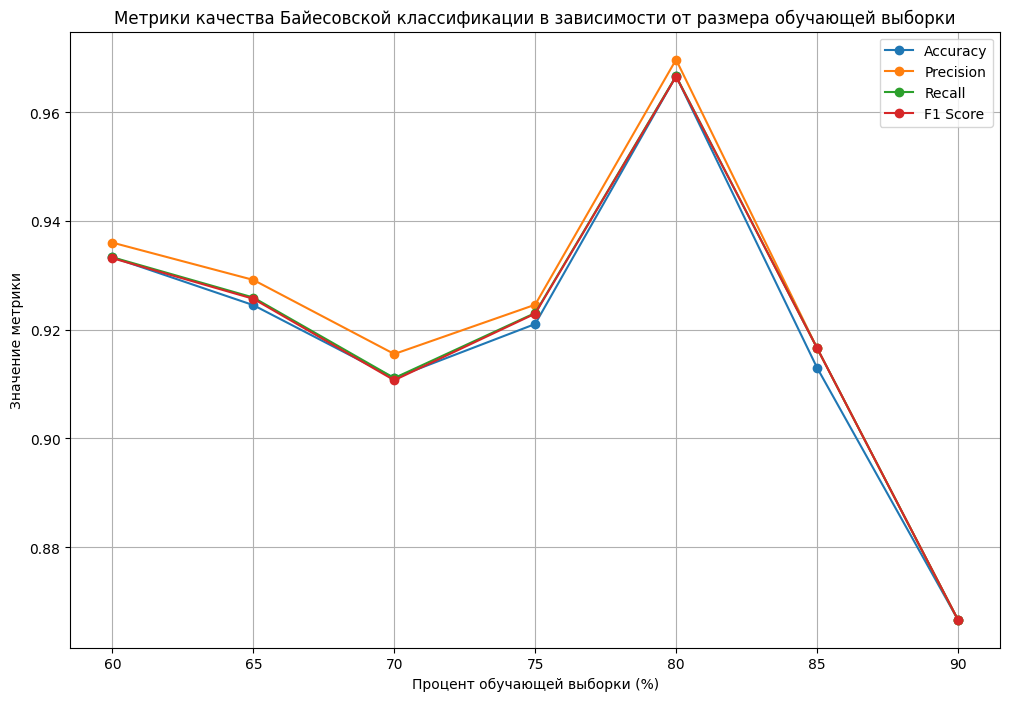

In [5]:
# Выводим график метрик
plt.figure(figsize=(12,8))

plt.plot(train_ratios, acc_list, label='Accuracy', marker='o')
plt.plot(train_ratios, prec_list, label='Precision', marker='o')
plt.plot(train_ratios, rec_list, label='Recall', marker='o')
plt.plot(train_ratios, f1_list, label='F1 Score', marker='o')

plt.title("Метрики качества Байесовской классификации в зависимости от размера обучающей выборки")
plt.xlabel("Процент обучающей выборки (%)")
plt.ylabel("Значение метрики")
plt.grid(True)
plt.legend()
plt.show()